In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_ScipySp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 1e2

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 1000

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell)
phiLargeEtaMax = 2 * phiLargeEtaMax - phic 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-2.14285227e-01, -2.04180069e-01, -1.94548883e-01, -1.85369438e-01,
       -1.76620545e-01, -1.68282011e-01, -1.60334587e-01, -1.52759929e-01,
       -1.45540552e-01, -1.38659794e-01, -1.32101770e-01, -1.25851344e-01,
       -1.19894087e-01, -1.14216250e-01, -1.08804726e-01, -1.03647024e-01,
       -9.87312388e-02, -9.40460236e-02, -8.95805637e-02, -8.53245517e-02,
       -8.12681636e-02, -7.74020363e-02, -7.37172457e-02, -7.02052866e-02,
       -6.68580524e-02, -6.36678168e-02, -6.06272160e-02, -5.77292315e-02,
       -5.49671740e-02, -5.23346680e-02, -4.98256371e-02, -4.74342898e-02,
       -4.51551061e-02, -4.29828253e-02, -4.09124331e-02, -3.89391506e-02,
       -3.70584229e-02, -3.52659088e-02, -3.35574708e-02, -3.19291654e-02,
       -3.03772339e-02, -2.88980943e-02, -2.74883322e-02, -2.61446935e-02,
       -2.48640769e-02, -2.36435263e-02, -2.24802244e-02, -2.13714860e-02,
       -2.03147519e-02, -1.93075828e-02, -1.83476540e-02, -1.74327496e-02,
       -1.65607579e-02, -

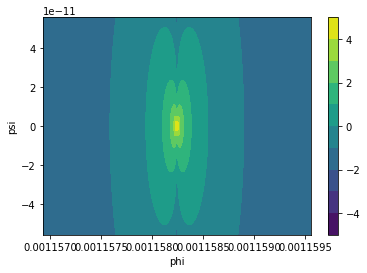

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

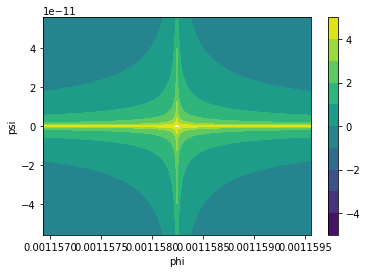

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [10]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [11]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

  (0, 0)	2.749548918932615e+28
  (0, 1)	-0.015265784231440115
  (0, 998)	-8.518817455931664e-15
  (1, 0)	-0.016295179142769515
  (1, 1)	2.5875079351404362e+28
  (1, 2)	-0.01681102884206995
  (1, 999)	-8.510547143076109e-15
  (2, 1)	-0.017368360694805133
  (2, 2)	2.4343413977952744e+28
  (2, 3)	-0.017919789314843986
  (2, 1000)	-8.502799085027085e-15
  (3, 2)	-0.018513879627417913
  (3, 3)	2.2896448431458765e+28
  (3, 4)	-0.01910328535136193
  (3, 1001)	-8.495540302369233e-15
  (4, 3)	-0.019736611813307898
  (4, 4)	2.1530220067787835e+28
  (4, 5)	-0.02036655447291163
  (4, 1002)	-8.488739898275612e-15
  (5, 4)	-0.021041761781450792
  (5, 5)	2.0240861362225716e+28
  (5, 6)	-0.021714973752925748
  (5, 1003)	-8.482368926996237e-15
  (6, 5)	-0.022434884870057265
  (6, 6)	1.9024610447091567e+28
  :	:
  (995997, 995997)	7.750897980634539e+24
  (995997, 995998)	-0.30706459138984343
  (995998, 995000)	-1.6207517940920221e-13
  (995998, 995997)	-0.2972112217693015
  (995998, 995998)	8.2713287288

In [12]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [13]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

  (0, 0)	2.749548918932615e+28
  (0, 1)	-0.015265784231440115
  (0, 998)	-8.518817455931664e-15
  (1, 0)	-0.016295179142769515
  (1, 1)	2.5875079351404362e+28
  (1, 2)	-0.01681102884206995
  (1, 999)	-8.510547143076109e-15
  (2, 1)	-0.017368360694805133
  (2, 2)	2.4343413977952744e+28
  (2, 3)	-0.017919789314843986
  (2, 1000)	-8.502799085027085e-15
  (3, 2)	-0.018513879627417913
  (3, 3)	2.2896448431458765e+28
  (3, 4)	-0.01910328535136193
  (3, 1001)	-8.495540302369233e-15
  (4, 3)	-0.019736611813307898
  (4, 4)	2.1530220067787835e+28
  (4, 5)	-0.02036655447291163
  (4, 1002)	-8.488739898275612e-15
  (5, 4)	-0.021041761781450792
  (5, 5)	2.0240861362225716e+28
  (5, 6)	-0.021714973752925748
  (5, 1003)	-8.482368926996237e-15
  (6, 5)	-0.022434884870057265
  (6, 6)	1.9024610447091567e+28
  :	:
  (995997, 995997)	7.750897980634539e+24
  (995997, 995998)	-0.30706459138984343
  (995998, 995000)	-7.768946310958409e-14
  (995998, 995997)	-0.2972112217693015
  (995998, 995998)	8.27132872880

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


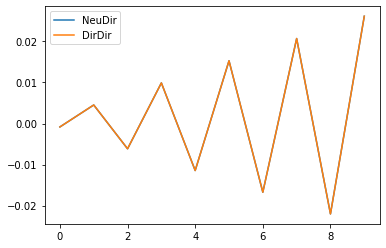

In [14]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-0.00083257+0.j  0.00451703+0.j -0.00615536+0.j  0.00989323+0.j
 -0.01145555+0.j  0.01529286+0.j -0.01674245+0.j  0.02071109+0.j
 -0.02202959+0.j  0.02614246+0.j]
[-0.00083257+0.j  0.00451703+0.j -0.00615536+0.j  0.00989323+0.j
 -0.01145555+0.j  0.01529286+0.j -0.01674245+0.j  0.02071109+0.j
 -0.02202959+0.j  0.02614246+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


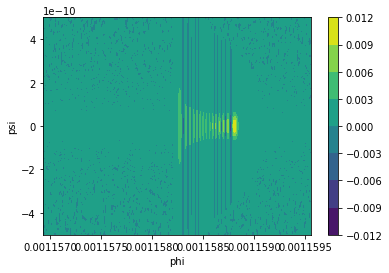

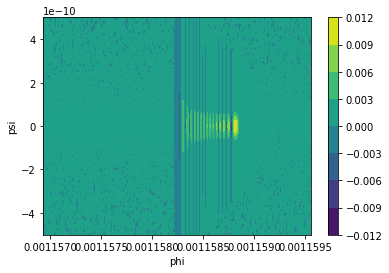

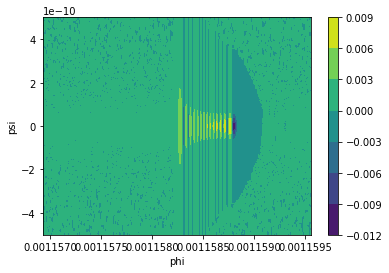

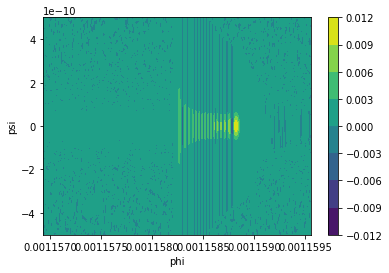

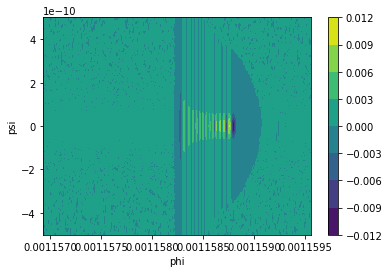

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

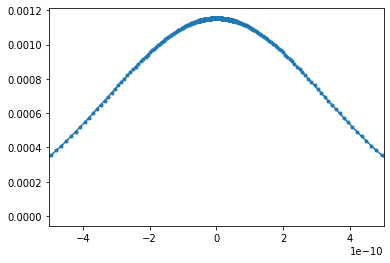

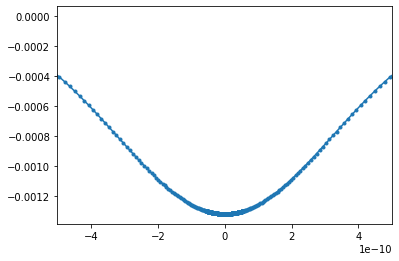

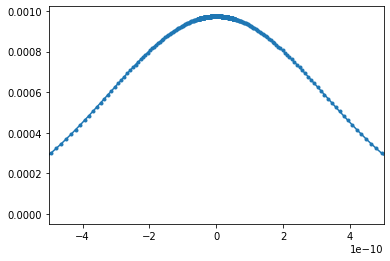

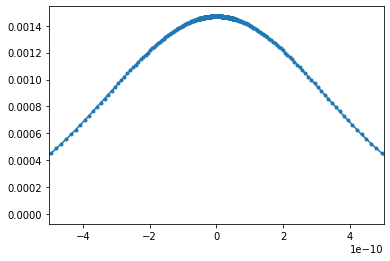

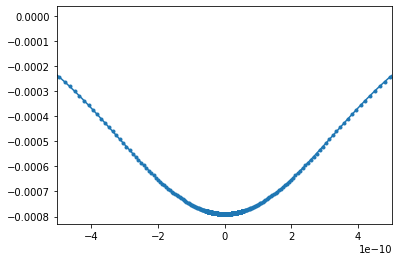

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

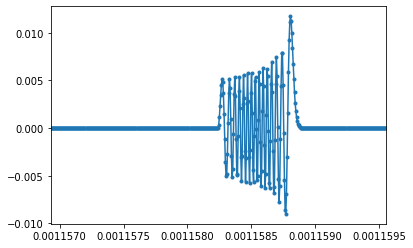

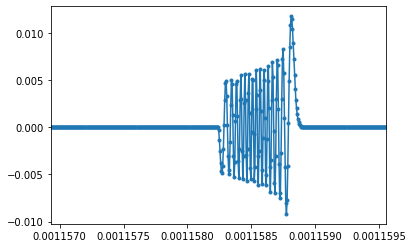

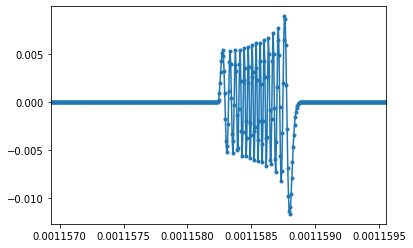

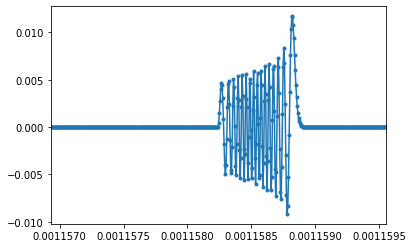

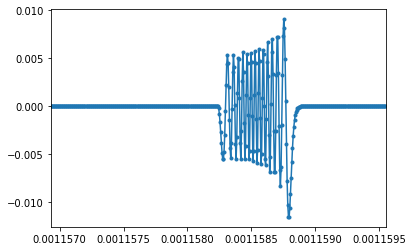

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    plt.show()

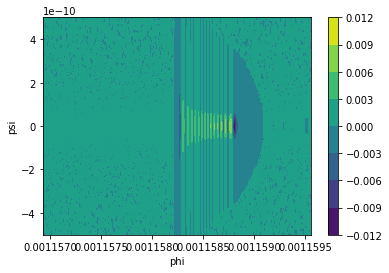

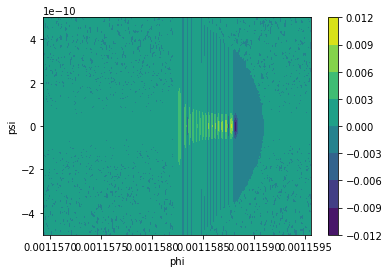

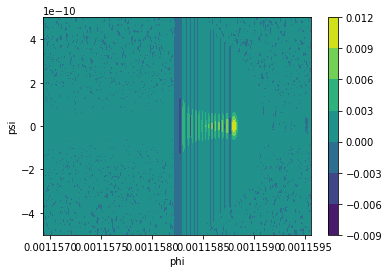

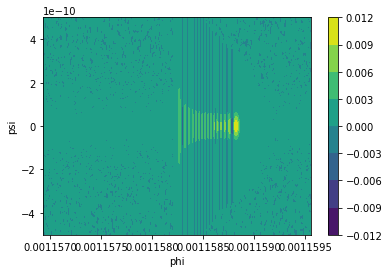

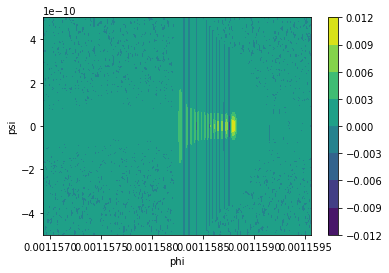

In [19]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

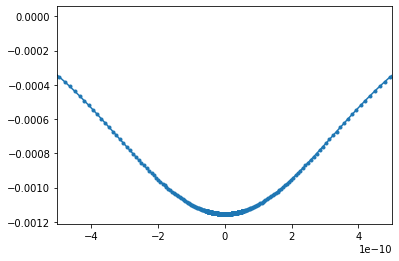

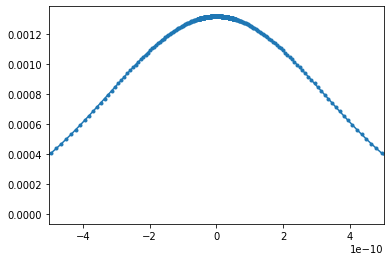

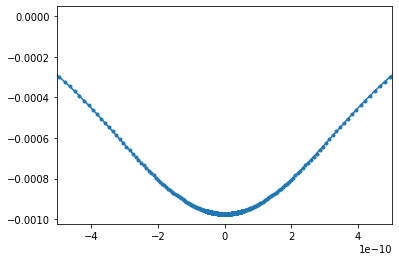

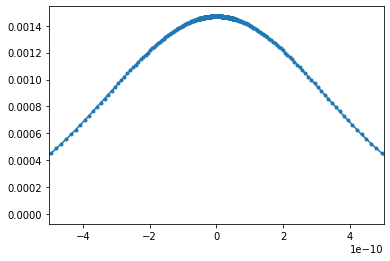

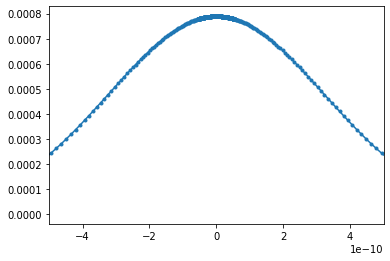

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

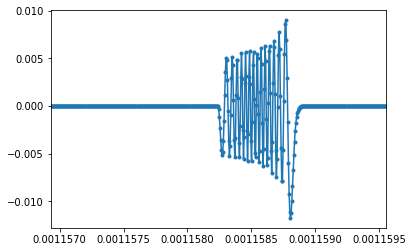

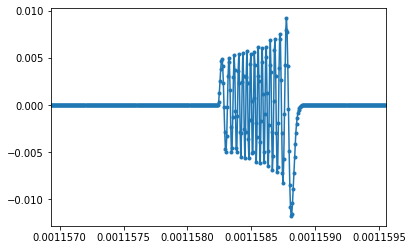

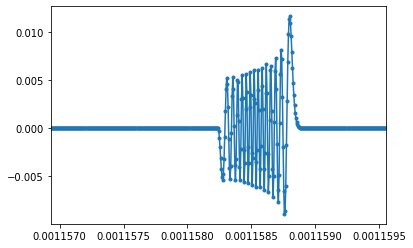

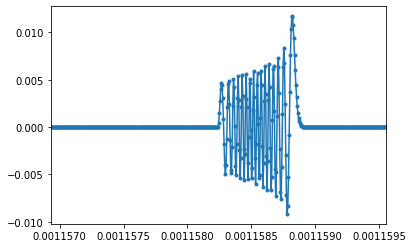

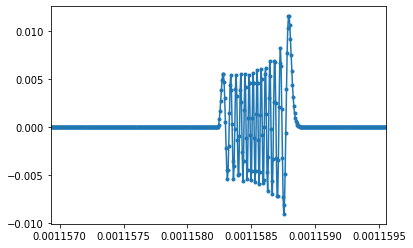

In [21]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    plt.show()